In [1]:
%load_ext cuml.accel
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR
from torch.utils.data import DataLoader, ConcatDataset
import re
import copy
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from cuml.manifold import TSNE, UMAP
from joblib import Parallel, delayed
from tqdm import tqdm

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [4]:
synth_ds = datasets.DatasetFolder(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds = datasets.DatasetFolder(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [5]:
train_ds = filter_by_elev(meas_ds, {14, 15, 16})
# valid_ds = filter_by_elev(meas_ds, {14, 15, 16})
test_ds  = filter_by_elev(meas_ds, {17})

ds_dict = {"train" : train_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "test": len(test_ds)}

In [6]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

train_loss = []
# val_loss = []
train_acc =[]
# val_acc = []

for i, seed in enumerate(seed_lst):
    print(f"Training Run {i}: seed {seed}")

    set_seed(seed)

    dataloaders = {
        "train": DataLoader(train_ds, batch_size=16, shuffle=True, num_workers = 6, pin_memory = True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        # "val": DataLoader(valid_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "test": DataLoader(test_ds, batch_size=16, shuffle=False, num_workers = 6, pin_memory = True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed))
    }
    # load pre-trained model
    model = models.resnet18(weights = None)

    # Replace final layer for the number of classes
    model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(model.fc.in_features, len(train_ds.class_to_idx))
    )
    
    # Define the loss function and optimizer
    criterion = nn.CrossEntropyLoss() # most common used nn for classification problems
    
    optimizer = optim.AdamW(model.parameters(), lr = 3e-4, weight_decay = 2e-4)
    
    scheduler = CosineAnnealingLR(optimizer, T_max = 200, eta_min = 3e-7)
        
    # move model to GPU
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    history = {
        "train_loss": [],
        # "val_loss" : [],
        "train_acc": [],
        # "val_acc" : []
    }
    
    # Training loops
    num_epochs = 200
    scaler = torch.amp.GradScaler('cuda')
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        if epoch == 0:
            print(f"First layer mean: {model.conv1.weight.data.mean():.6f}")
        for phase in ["train"]:
            if phase == "train":
                model.train()
            else:
                model.eval()
    
            running_loss = 0.0
            running_corrects = 0 # correct predictions
            
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device, non_blocking = True)
                labels = labels.to(device, non_blocking = True)
    
                optimizer.zero_grad(set_to_none = True) # clear the gradient from previous iteration
    
                with torch.set_grad_enabled(phase == "train"):
                    with torch.amp.autocast('cuda'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels) # check if output and labels match
    
                    if phase == "train":
                        scaler.scale(loss).backward()
                        scaler.step(optimizer)
                        scaler.update()
    
                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()
    
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
            
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)
    
            print(f"{phase} Loss: {epoch_loss:.10f} Acc: {epoch_acc:.10f}")
    
        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")
        
    print("Training complete!")
    
    train_loss.append(history["train_loss"])
    # val_loss.append(history["val_loss"])
    train_acc.append(history["train_acc"])
    # val_acc.append(history["val_acc"])
    
    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/Extras/training_on_meas/wo_aug/rn18_seed{seed}_b16.pth"))

train_loss = np.array(train_loss)
# val_loss = np.array(val_loss)
train_acc = np.array(train_acc)
# val_acc = np.array(val_acc)

Training Run 0: seed 10
Epoch 0
First layer mean: 0.000224
train Loss: 1.3388506247 Acc: 0.5359801489
Epoch 0 LR: 0.0002999815
Epoch 1
train Loss: 0.1729023448 Acc: 0.9640198511
Epoch 1 LR: 0.0002999261
Epoch 2
train Loss: 0.0295134043 Acc: 0.9987593052
Epoch 2 LR: 0.0002998336
Epoch 3
train Loss: 0.0395813389 Acc: 0.9913151365
Epoch 3 LR: 0.0002997043
Epoch 4
train Loss: 0.0194125231 Acc: 0.9975186104
Epoch 4 LR: 0.0002995381
Epoch 5
train Loss: 0.0166715358 Acc: 0.9987593052
Epoch 5 LR: 0.0002993350
Epoch 6
train Loss: 0.0078205872 Acc: 1.0000000000
Epoch 6 LR: 0.0002990950
Epoch 7
train Loss: 0.0059150667 Acc: 1.0000000000
Epoch 7 LR: 0.0002988184
Epoch 8
train Loss: 0.0034932432 Acc: 0.9987593052
Epoch 8 LR: 0.0002985050
Epoch 9
train Loss: 0.0369742842 Acc: 0.9900744417
Epoch 9 LR: 0.0002981551
Epoch 10
train Loss: 0.0801046529 Acc: 0.9776674938
Epoch 10 LR: 0.0002977686
Epoch 11
train Loss: 0.0478502082 Acc: 0.9875930521
Epoch 11 LR: 0.0002973457
Epoch 12
train Loss: 0.0276560974

# Model trained on Measured 14, 15, 16

## PCC

In [11]:
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: Seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/training_on_meas/wo_aug/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0: Seed 10
Test Accuracy: 1.0000
Evaluating Run 1: Seed 42
Test Accuracy: 1.0000
Evaluating Run 2: Seed 100
Test Accuracy: 1.0000
Evaluating Run 3: Seed 123
Test Accuracy: 0.9944
Evaluating Run 4: Seed 666
Test Accuracy: 1.0000
Evaluating Run 5: Seed 777
Test Accuracy: 1.0000
Evaluating Run 6: Seed 849
Test Accuracy: 0.9981
Evaluating Run 7: Seed 1000
Test Accuracy: 1.0000
Evaluating Run 8: Seed 1111
Test Accuracy: 1.0000
Evaluating Run 9: Seed 1234
Test Accuracy: 1.0000


## Normalised TSNE

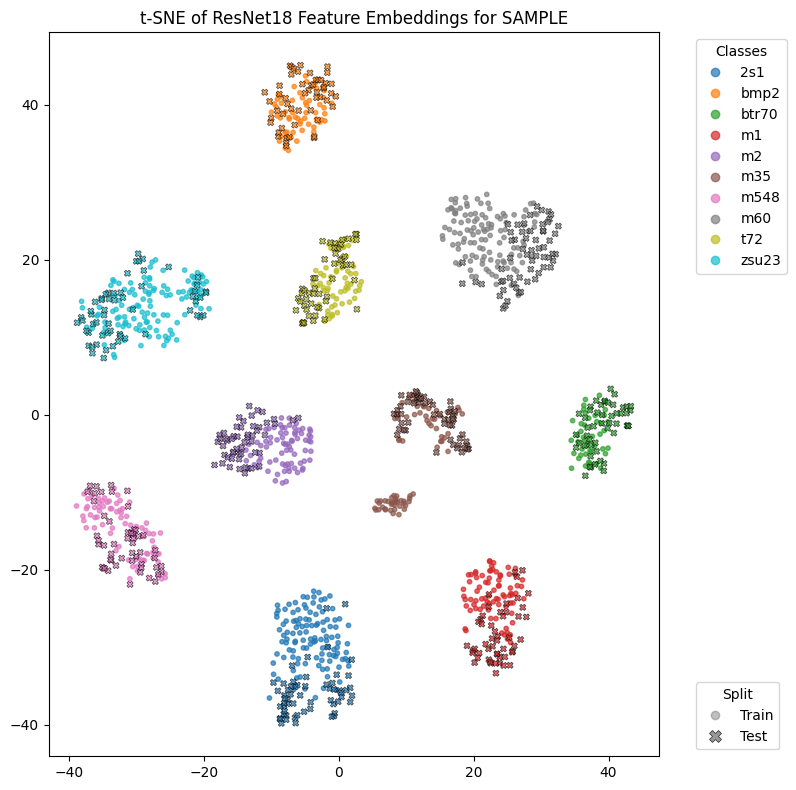

In [6]:
combined_ds = ConcatDataset([train_ds, test_ds])
combined_loader = DataLoader(combined_ds, batch_size=64, shuffle=False, num_workers=6, pin_memory=True, persistent_workers=True, prefetch_factor=4)

device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Extras/training_on_meas/wo_aug/rn18_seed10_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in combined_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

# features = features / np.linalg.norm(features, axis=1, keepdims=True)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate_method="adaptive",
    metric = "cosine"
)

features_2d = tsne.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:len(train_ds), 0],
    features_2d[:len(train_ds), 1],
    c=labels_list[:len(train_ds)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d[len(train_ds):, 0],
    features_2d[len(train_ds):, 1],
    c=labels_list[len(train_ds):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="Train"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Test"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("t-SNE of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

## Distance

In [25]:
device = torch.cuda.set_device("cuda:0")
seed_lst = [10]
for i, seed in enumerate(seed_lst):
    set_seed(seed)
    model = models.resnet18(weights = None) # dont load ImageNet Weights
    # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(model.fc.in_features, len(synth_ds.class_to_idx))
    )
    # Load your trained weights
    model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/training_on_meas/wo_aug/rn18_seed10_b16.pth"),
        map_location=device
    ))

    # this gives the synth_features and synth_labels
    train_meas_features, train_meas_labels, _ = _get_features_and_preds_from_model(model, train_ds, device, seed)
    test_meas_features, test_meas_labels, test_meas_preds = _get_features_and_preds_from_model(model, test_ds, device, seed)

cosine_d_true_class, cosine_n_true_class = k_nearest_neighbors_by_true_class(test_meas_features, test_meas_labels, train_meas_features, train_meas_labels, metric = "cosine")

print(f"Neighbors = 1")

results, azim_diffs = azim_agreement_analysis_by_class(
    test_ds, test_meas_labels, test_meas_preds,
    train_ds, cosine_n_true_class,
    q_values=[5, 10, 15],
    k = 1
)

results, azim_diffs = azim_agreement_analysis_by_class(
    test_ds, test_meas_labels, test_meas_preds,
    train_ds, cosine_n_true_class,
    q_values=[5, 10, 15],
    k = 1, normalise = False

)
print("-" * 30)
print(f"Neighbors = 5")

results, azim_diffs = azim_agreement_analysis_by_class(
    test_ds, test_meas_labels, test_meas_preds,
    train_ds, cosine_n_true_class,
    q_values=[5, 10, 15],
    k = 5
)

results, azim_diffs = azim_agreement_analysis_by_class(
    test_ds, test_meas_labels, test_meas_preds,
    train_ds, cosine_n_true_class,
    q_values=[5, 10, 15],
    k = 5, normalise = False

)

Neighbors = 1
Class       q= 5  q=10  q=15
----------------------------
2s1         0.293  0.517  0.655  (n=58)
bmp2        0.481  0.692  0.808  (n=52)
btr70       0.469  0.735  0.837  (n=49)
m1          0.471  0.569  0.588  (n=51)
m2          0.245  0.491  0.623  (n=53)
m35         0.679  0.906  1.000  (n=53)
m548        0.547  0.698  0.811  (n=53)
m60         0.467  0.667  0.817  (n=60)
t72         0.731  0.904  0.962  (n=52)
zsu23       0.500  0.690  0.741  (n=58)
----------------------------
Overall     0.486  0.685  0.783  (n=539)
Class       q= 5  q=10  q=15
----------------------------
2s1         17.000  30.000  38.000  (n=58)
bmp2        25.000  36.000  42.000  (n=52)
btr70       23.000  36.000  41.000  (n=49)
m1          24.000  29.000  30.000  (n=51)
m2          13.000  26.000  33.000  (n=53)
m35         36.000  48.000  53.000  (n=53)
m548        29.000  37.000  43.000  (n=53)
m60         28.000  40.000  49.000  (n=60)
t72         38.000  47.000  50.000  (n=52)
zsu23       2

# Model trained on Synth 14, 15, 16

## PCC

In [10]:
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i in range(10):
    print(f"Evaluating Run {i}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Experiment_1/wo_aug/rn18_run{i}_b16.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0
Test Accuracy: 0.6827
Evaluating Run 1
Test Accuracy: 0.6698
Evaluating Run 2
Test Accuracy: 0.6419
Evaluating Run 3
Test Accuracy: 0.7143
Evaluating Run 4
Test Accuracy: 0.6178
Evaluating Run 5
Test Accuracy: 0.7570
Evaluating Run 6
Test Accuracy: 0.6308
Evaluating Run 7
Test Accuracy: 0.7217
Evaluating Run 8
Test Accuracy: 0.6642
Evaluating Run 9
Test Accuracy: 0.7291


## Normalised TSNE

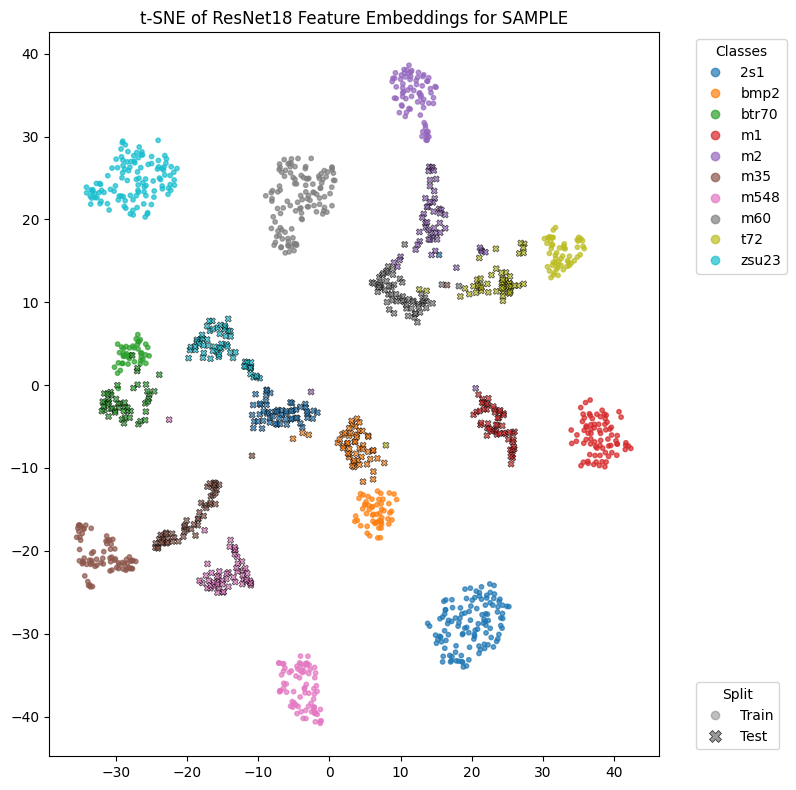

In [7]:
synth_train_ds = filter_by_elev(synth_ds, {14, 15, 16})

combined_ds = ConcatDataset([synth_train_ds, test_ds])
combined_loader = DataLoader(combined_ds, batch_size=64, shuffle=False, num_workers=6, pin_memory=True, persistent_workers=True, prefetch_factor=4)

device = torch.cuda.set_device("cuda:0")
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(synth_train_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Experiment_1/wo_aug/rn18_run0_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in combined_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

# features = features / np.linalg.norm(features, axis=1, keepdims=True)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate_method="adaptive",
    metric  = "cosine"
)

features_2d = tsne.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(synth_train_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:len(synth_train_ds), 0],
    features_2d[:len(synth_train_ds), 1],
    c=labels_list[:len(synth_train_ds)],
    cmap="tab10",
    s=10,
    alpha=0.7,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d[len(synth_train_ds):, 0],
    features_2d[len(synth_train_ds):, 1],
    c=labels_list[len(synth_train_ds):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="Train"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Test"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("t-SNE of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

## Distance

In [26]:
synth_train_ds = filter_by_elev(synth_ds, {14, 15, 16})

device = torch.cuda.set_device("cuda:0")
seed_lst = [10]
for i, seed in enumerate(seed_lst):
    set_seed(seed)
    model = models.resnet18(weights = None) # dont load ImageNet Weights
    # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(model.fc.in_features, len(synth_ds.class_to_idx))
    )
    # Load your trained weights
    model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Experiment_1/wo_aug/rn18_run0_b16.pth"),
        map_location=device
    ))

    # this gives the synth_features and synth_labels
    train_synth_features, train_synth_labels, _ = _get_features_and_preds_from_model(model, synth_train_ds, device, seed)
    test_meas_features, test_meas_labels, test_meas_preds = _get_features_and_preds_from_model(model, test_ds, device, seed)

cosine_d_true_class, cosine_n_true_class = k_nearest_neighbors_by_true_class(test_meas_features, test_meas_labels, train_synth_features, train_synth_labels, metric = "cosine")

print(f"Neighbors = 1")

results, azim_diffs = azim_agreement_analysis_by_class(
    test_ds, test_meas_labels, test_meas_preds,
    synth_train_ds, cosine_n_true_class,
    q_values=[5, 10, 15],
    k = 1
)

results, azim_diffs = azim_agreement_analysis_by_class(
    test_ds, test_meas_labels, test_meas_preds,
    synth_train_ds, cosine_n_true_class,
    q_values=[5, 10, 15],
    k = 1, normalise = False

)
print("-" * 30)
print(f"Neighbors = 5")

results, azim_diffs = azim_agreement_analysis_by_class(
    test_ds, test_meas_labels, test_meas_preds,
    synth_train_ds, cosine_n_true_class,
    q_values=[5, 10, 15],
    k = 5
)

results, azim_diffs = azim_agreement_analysis_by_class(
    test_ds, test_meas_labels, test_meas_preds,
    synth_train_ds, cosine_n_true_class,
    q_values=[5, 10, 15],
    k = 5, normalise = False

)

Neighbors = 1
Class       q= 5  q=10  q=15
----------------------------
2s1         0.115  0.269  0.500  (n=26)
bmp2        0.235  0.431  0.549  (n=51)
btr70       0.163  0.347  0.429  (n=49)
m1          0.146  0.268  0.463  (n=41)
m2          0.167  0.278  0.333  (n=18)
m35         0.281  0.500  0.656  (n=32)
m548        0.276  0.414  0.448  (n=29)
m60         0.255  0.418  0.545  (n=55)
t72         0.245  0.388  0.633  (n=49)
zsu23       0.056  0.389  0.389  (n=18)
----------------------------
Overall     0.207  0.378  0.514  (n=368)
Class       q= 5  q=10  q=15
----------------------------
2s1         3.000  7.000  13.000  (n=26)
bmp2        12.000  22.000  28.000  (n=51)
btr70       8.000  17.000  21.000  (n=49)
m1          6.000  11.000  19.000  (n=41)
m2          3.000  5.000  6.000  (n=18)
m35         9.000  16.000  21.000  (n=32)
m548        8.000  12.000  13.000  (n=29)
m60         14.000  23.000  30.000  (n=55)
t72         12.000  19.000  31.000  (n=49)
zsu23       1.000  7.0